**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: --/--/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [ ]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.modeling.Evaluation import Evaluation
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

In [ ]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()

## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [ ]:
# ---- Experiment settings ----
TAG = "full-features_no-weight"
SCHEMA_DATE = "080626"

# ---- Paths ----
PATH_DATA_RAW = "../../data/raw"
PATH_MODELS = "../../models"
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
PROCESS = "annealing_iacs"

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of σ²_aleat as fraction of Var(y)
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# 2. Data

## 2.1 Schema data

In [7]:
# Schema dataset.
df_raw_schema = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_SCHEMA_DATA))
df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
df_schema

,purity,iacs,temperature,time,iacs_final
0,99.9,88.260,623.0,30.0,88.350000
1,99.9,88.260,623.0,60.0,88.655000
2,99.9,88.260,623.0,90.0,88.800000
3,99.9,99.825,573.0,30.0,102.340000
4,99.9,99.390,573.0,30.0,102.230000
5,99.9,99.390,588.0,30.0,101.346667
6,99.9,99.230,573.0,30.0,101.355000
7,99.9,98.720,573.0,30.0,101.480000
17,99.9,100.250,573.0,30.0,102.755000


## 2.2 Literature data

In [8]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME))
df_raw.head()

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98


In [9]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "iacs",
)

# Keep only copper rows and the schema columns.
mask_cu = df_with_masks.has_Cu == True
df_lit = df_with_masks[mask_cu]
df_lit = df_lit[FEATURES + [TARGET]]

assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df_lit.shape}")
df_lit.head()

Dataset: (87, 5)


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0
3,99.98,96.0,473.0,30.0,99.0
4,99.98,95.0,523.0,600.0,98.0


## 2.3 Concat dataset

In [ ]:
df = pd.concat([df_schema, df_lit], ignore_index=True)
df["weight_col"] = 1.0
df.loc[: len(df_schema)-1, "weight_col"] = WEIGHT_ON_ESSAY_ROWS
df

,purity,iacs,temperature,time,iacs_final,weight_col
0,99.9,88.260,623.0,30.0,88.350,3.0
1,99.9,88.260,623.0,60.0,88.655,3.0
2,99.9,88.260,623.0,90.0,88.800,3.0
3,99.9,99.825,573.0,30.0,102.340,3.0
4,99.9,99.390,573.0,30.0,102.230,3.0
...,...,...,...,...,...,...
91,99.0,88.000,673.0,30.0,97.000,1.0
92,99.0,87.000,473.0,30.0,89.000,1.0
93,99.0,87.000,573.0,30.0,92.000,1.0
94,99.0,87.000,673.0,30.0,95.000,1.0


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [33]:
df

,purity,iacs,temperature,time,iacs_final,weight_col
0,99.9,88.260,623.0,30.0,88.350,3.0
1,99.9,88.260,623.0,60.0,88.655,3.0
2,99.9,88.260,623.0,90.0,88.800,3.0
3,99.9,99.825,573.0,30.0,102.340,3.0
4,99.9,99.390,573.0,30.0,102.230,3.0
...,...,...,...,...,...,...
91,99.0,88.000,673.0,30.0,97.000,1.0
92,99.0,87.000,473.0,30.0,89.000,1.0
93,99.0,87.000,573.0,30.0,92.000,1.0
94,99.0,87.000,673.0,30.0,95.000,1.0


In [ ]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(PATH_MODELS, PROCESS, TAG, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    sample_weight="weight_col",
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.87 GB / 31.57 GB (34.4%)
Disk Space Avail:   753.82 GB / 932.08 GB (80.9%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_a"
Train Data Rows:    96
Train Data Columns: 5
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regre

In [13]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-3.851428,root_mean_squared_error,0.115927,75.705223,0.000000,0.004968,2,True,10
1,XGBoost_BAG_L1,-4.107960,root_mean_squared_error,0.017617,0.855430,0.017617,0.855430,1,True,7
2,CatBoost_BAG_L1,-4.303946,root_mean_squared_error,0.011583,50.448194,0.011583,50.448194,1,True,4
3,NeuralNetTorch_BAG_L1,-4.382198,root_mean_squared_error,0.040327,16.519770,0.040327,16.519770,1,True,8
4,ExtraTreesMSE_BAG_L1,-4.441144,root_mean_squared_error,0.036079,0.426718,0.036079,0.426718,1,True,5
5,RandomForestMSE_BAG_L1,-4.488315,root_mean_squared_error,0.041529,0.637226,0.041529,0.637226,1,True,3
6,LightGBMLarge_BAG_L1,-4.667237,root_mean_squared_error,0.025014,2.911378,0.025014,2.911378,1,True,9
7,NeuralNetFastAI_BAG_L1,-5.656535,root_mean_squared_error,0.046401,7.876861,0.046401,7.876861,1,True,6
8,LightGBM_BAG_L1,-6.892251,root_mean_squared_error,0.004003,1.084073,0.004003,1.084073,1,True,2
9,LightGBMXT_BAG_L1,-7.381406,root_mean_squared_error,0.007201,0.584046,0.007201,0.584046,1,True,1


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [14]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

train_h2o = h2o.H2OFrame(df[FEATURES + [TARGET, "weight_col"]])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()

aml_h2o = H2OAutoML(
    max_runtime_secs=TIME_LIMIT_A,
    nfolds=NUM_BAG_FOLDS_A,
    keep_cross_validation_predictions=True,
    sort_metric="RMSE",
    seed=42,
)
aml_h2o.train(
    x=FEATURES,
    y=TARGET,
    training_frame=train_h2o,
    weights_column="weight_col",
)

aml_h2o.leaderboard.head(10)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpho6af9dm
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpho6af9dm\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpho6af9dm\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 29 days
H2O_cluster_name:,H2O_from_python_fmfoa_lk91lo
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
10:58:19.182: AutoML: XGBoost is not available; skipping it.


10:58:19.640: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 134.0.

█
10:58:20.868: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

█
10:58:20.997: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

████████
10:58:22.966: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column f

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
StackedEnsemble_BestOfFamily_3_AutoML_1_20260610_105819,3.80624,14.4875,2.06951,0.0489857,14.4875
GBM_grid_1_AutoML_1_20260610_105819_model_519,4.10101,16.8183,2.09821,0.0542972,16.8183
GBM_grid_1_AutoML_1_20260610_105819_model_187,4.29306,18.4303,2.15179,0.0579293,18.4303
GBM_grid_1_AutoML_1_20260610_105819_model_523,4.36551,19.0577,2.29247,0.0583896,19.0577
GBM_grid_1_AutoML_1_20260610_105819_model_206,4.46113,19.9017,2.18792,0.0588134,19.9017
GBM_grid_1_AutoML_1_20260610_105819_model_31,4.53065,20.5268,2.20186,0.0597386,20.5268
GBM_grid_1_AutoML_1_20260610_105819_model_319,4.56617,20.8499,2.48209,0.0600613,20.8499
StackedEnsemble_AllModels_3_AutoML_1_20260610_105819,4.56825,20.8689,2.83316,0.0593482,20.8689
GBM_grid_1_AutoML_1_20260610_105819_model_96,4.56894,20.8753,2.48162,0.0616016,20.8753
GBM_grid_1_AutoML_1_20260610_105819_model_382,4.60926,21.2453,2.88433,0.0592181,21.2453


In [15]:
rmse_agl = abs(predictor_a.leaderboard(silent=True)["score_val"].iloc[0])
rmse_h2o = aml_h2o.leader.model_performance(xval=True).rmse()

print(f"AutoGluon  leader  CV RMSE : {rmse_agl:.4f}")
print(f"H2O AutoML leader  CV RMSE : {rmse_h2o:.4f}")
print(f"Difference (AGL - H2O)     : {rmse_agl - rmse_h2o:+.4f}")

AutoGluon  leader  CV RMSE : 3.8514
H2O AutoML leader  CV RMSE : 3.8062
Difference (AGL - H2O)     : +0.0452


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [16]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(96,)  any NaN? False


In [17]:
mu_oof

0      92.412903
1      92.055412
2      91.336143
3     101.427307
4     101.331932
         ...    
91     95.666725
92     89.484596
93     91.336807
94     96.396713
95     91.836929
Name: iacs_final, Length: 96, dtype: float32

In [ ]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 96)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [ ]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000005  (OK)

Non-zero weights:
  CatBoost_BAG_L1                 0.0417
  NeuralNetFastAI_BAG_L1          0.0833
  XGBoost_BAG_L1                  0.5417
  NeuralNetTorch_BAG_L1           0.3333


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [ ]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof):.4f}")
print(f"  max    = {sigma2_epist_oof.max():.4f}")

sigma2_epist_oof stats:
  mean   = 4.1467
  median = 1.3823
  max    = 70.0660


In [21]:
mu_oof

0      92.412903
1      92.055412
2      91.336143
3     101.427307
4     101.331932
         ...    
91     95.666725
92     89.484596
93     91.336807
94     96.396713
95     91.836929
Name: iacs_final, Length: 96, dtype: float32

In [22]:
mu_recomputed

array([ 92.41289962,  92.05540983,  91.33614697, 101.42730692,
       101.33192872, 101.70400102, 101.28571908, 100.08679919,
       100.36631962,  99.23054205,  99.85629547,  99.53408947,
        97.86168482,  97.4414147 ,  97.31102757,  96.72094531,
        74.57476676,  85.17217193,  75.53756473,  73.24967179,
        78.40278881,  80.96691978,  85.59720377,  87.60181744,
        79.87345796,  70.83381861,  75.18131438,  83.43646843,
        82.48939586,  85.12203071,  84.48538135,  87.69147459,
        80.35336487,  83.07835824,  85.46474567,  69.49600249,
        75.33038277,  79.47235822,  59.88116732,  59.90446188,
        60.00943148,  63.0112075 ,  97.79913785, 100.42808399,
       100.76137894, 101.43467868, 101.8881448 , 101.98308726,
       103.00296883, 103.26131629, 102.60697199, 100.78422403,
        95.4531696 ,  96.87823785,  98.72845794,  94.51686959,
        95.51080407,  96.23160091,  91.87851813,  93.63672395,
        95.0273139 ,  90.49808753,  92.46625315,  94.17

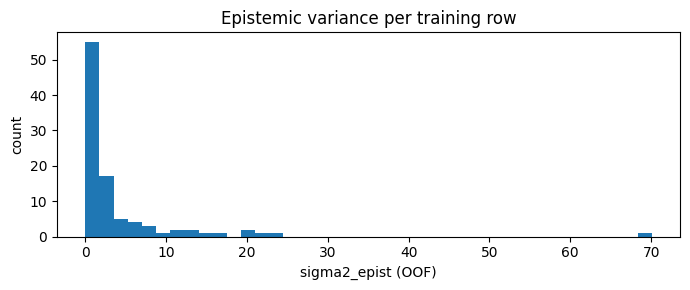

In [23]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

sigma2_epist_oof stats:
  mean   = 8.0813
  median = 2.5440
  max    = 85.8019


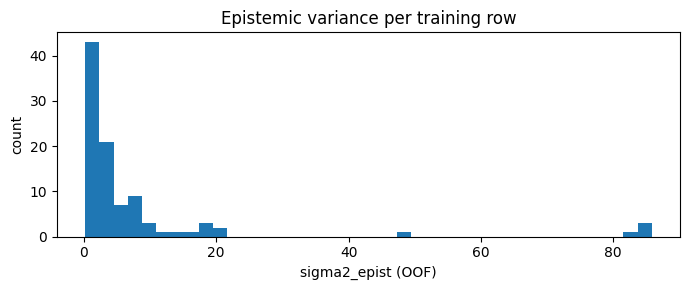

In [ ]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [ ]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 96
  n_truncated          = 35
  pct_truncated        = 36.458333333333336
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 233.58612741856555
  r_tilde_sq_mean      = 11.412100478847947
  r_tilde_sq_median    = 0.791321999111773


# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [ ]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(PATH_MODELS, PROCESS, TAG, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.10 GB / 31.57 GB (22.5%)
Disk Space Avail:   753.65 GB / 932.08 GB (80.9%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_b"
Train Data Rows:    96
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.4535508674210655, -13.815510557964274, -4.28612, 7.42963)
	If 'regres

In [27]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.288546,root_mean_squared_error,0.114032,17.627533,0.000000,0.009998,2,True,10
1,NeuralNetFastAI_BAG_L1,-6.324120,root_mean_squared_error,0.051017,8.410446,0.051017,8.410446,1,True,6
2,CatBoost_BAG_L1,-6.725037,root_mean_squared_error,0.005370,1.421584,0.005370,1.421584,1,True,4
3,LightGBM_BAG_L1,-6.736885,root_mean_squared_error,0.004007,1.209623,0.004007,1.209623,1,True,2
4,LightGBMXT_BAG_L1,-6.740740,root_mean_squared_error,0.002984,1.104294,0.002984,1.104294,1,True,1
5,LightGBMLarge_BAG_L1,-6.898887,root_mean_squared_error,0.006005,1.540831,0.006005,1.540831,1,True,9
6,NeuralNetTorch_BAG_L1,-6.930295,root_mean_squared_error,0.063015,9.207089,0.063015,9.207089,1,True,8
7,XGBoost_BAG_L1,-7.079395,root_mean_squared_error,0.011977,0.707630,0.011977,0.707630,1,True,7
8,ExtraTreesMSE_BAG_L1,-7.299063,root_mean_squared_error,0.067527,0.515890,0.067527,0.515890,1,True,5
9,RandomForestMSE_BAG_L1,-7.489829,root_mean_squared_error,0.065312,0.576064,0.065312,0.576064,1,True,3


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [ ]:
# Build the full OOF predictive distribution.
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
print(cal_before)

=== Calibration BEFORE recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.395833 -0.104167
1   0.80            0.718750 -0.081250
2   0.90            0.833333 -0.066667
3   0.95            0.864583 -0.085417


In [ ]:
# Fit a scalar recalibration factor to pull coverage at α=0.9 to nominal.
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
print(cal_after)

Recalibration scalar c = 1.4549

=== Calibration AFTER recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.593750  0.093750
1   0.80            0.843750  0.043750
2   0.90            0.916667  0.016667
3   0.95            0.937500 -0.012500


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [30]:
df.head(5)

,purity,iacs,temperature,time,iacs_final,weight_col
0,99.9,88.260,623.0,30.0,88.350,3.0
1,99.9,88.260,623.0,60.0,88.655,3.0
2,99.9,88.260,623.0,90.0,88.800,3.0
3,99.9,99.825,573.0,30.0,102.340,3.0
4,99.9,99.390,573.0,30.0,102.230,3.0


In [ ]:
preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
)
preds

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction
0,90.720959,6.560756,1.411706,16.876059,4.108048,90.720955
1,91.637570,11.535751,1.411706,27.407100,5.235179,91.637573
2,90.244189,3.083700,1.411706,9.515848,3.084777,90.244186
3,101.533786,0.053893,1.411706,3.102371,1.761355,101.533783
4,101.411464,0.044456,1.411706,3.082395,1.755675,101.411461


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [ ]:
# ---- Experiment directory (tagged per run, see TAG in 1.1) ----
experiment_dir = os.path.join(PATH_MODELS, PROCESS, TAG)
os.makedirs(experiment_dir, exist_ok=True)

artifacts_path = os.path.join(experiment_dir, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")

In [32]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "PATH_DATA_RAW": PATH_DATA_RAW,
    "PATH_MODELS": PATH_MODELS,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
}

config_path = os.path.join(experiment_dir, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")

Saved to: ../../models\annealing_iacs\full-features_no-weight\global_config.txt


In [ ]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(experiment_dir, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(experiment_dir, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(experiment_dir, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {experiment_dir}")

                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  3.996120  2.499520  3.187536  0.885691
1          H2O AutoML (leader)  3.728819  2.034518  2.555203  0.900472
Saved to: ../../models\annealing_iacs\full-features_no-weight


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
